Introduction

This notebook implements and evaluates neural network models for image classification on the CIFAR-10 dataset. The objective is to compare a simple linear baseline (Softmax Regression) with a Convolutional Neural Network (CNN), and to investigate how key hyperparameters affect model performance.

Experiments are conducted to analyse the effects of network depth, learning rate, and mini-batch size. A final model is selected based on validation performance and evaluated on a held-out test set.

Imports

The following libraries are used for implementing and training neural network models. PyTorch is used for building and training models, torchvision for loading the CIFAR-10 dataset, and matplotlib for visualising results.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

Device Setup

The model is configured to use a GPU if available, otherwise it falls back to CPU. This significantly improves training speed when running deep neural networks.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


Reproducibility

A fixed random seed is used to ensure reproducible results across runs. This controls sources of randomness in PyTorch, NumPy, and Python’s random module.

In [7]:
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Data Preparation

The CIFAR-10 dataset is loaded and split into training (45,000), validation (5,000), and test (10,000) sets. Images are normalised using the dataset mean and standard deviation to improve training stability.

DataLoaders are used to handle batching and shuffling of data during training and evaluation.

The chosen batch size of 256 is used for the final model based on experimental results.

In [8]:
# Normalise images to mean/std of CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

# Download dataset
full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=transform)
test_set   = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)

# Split training into train (45k) and validation (5k)
train_set, val_set = random_split(full_train, [45000, 5000],
                                   generator=torch.Generator().manual_seed(SEED))

# Create data loaders
train_loader = DataLoader(
    train_set,
    batch_size=256,          
    shuffle=True,
    num_workers=4,           
    pin_memory=True          
)

val_loader = DataLoader(
    val_set,
    batch_size=256,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_set,
    batch_size=256,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")


100.0%
c:\Users\kiera\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 45000, Val: 5000, Test: 10000


Data Visualisation

A sample of images from the training set is visualised to verify that the data has been loaded and preprocessed correctly. The images are unnormalised for display purposes and labelled according to their respective classes.

In [ ]:
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

images, labels = next(iter(train_loader))

# move to CPU just in case (safe for plotting)
images = images.cpu()
labels = labels.cpu()

fig, axes = plt.subplots(1, 8, figsize=(16, 2))

for i in range(8):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * [0.247, 0.243, 0.261] + [0.491, 0.482, 0.446]
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')

plt.show()

Softmax Regression (Baseline Model)

A Softmax Regression model is implemented as a linear classifier that maps flattened image inputs to class scores. This model serves as a baseline to highlight the limitations of linear approaches on image data, as it cannot capture spatial or hierarchical features.

In [15]:
class SoftmaxRegression(nn.Module):
    def __init__(self):
        super(SoftmaxRegression, self).__init__()
        self.linear = nn.Linear(3 * 32 * 32, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten the image
        return self.linear(x)

Training Function

A reusable training function is used to train models and evaluate performance on a validation set after each epoch. The function tracks training loss, validation loss, and validation accuracy to monitor learning progress and detect overfitting.

In [10]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=20):
    model = model.to(device)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}%"
        )

    return history

In [16]:
# Initialise model, loss function, and optimizer
softmax_model = SoftmaxRegression().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(softmax_model.parameters(), lr=0.01)

# Train the model
print("Training Softmax Regression...")
softmax_history = train_model(
    softmax_model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=20
)

Training Softmax Regression...
Epoch 1/20 | Train Loss: 1.8844 | Val Loss: 1.8427 | Val Acc: 37.14%
Epoch 2/20 | Train Loss: 1.7868 | Val Loss: 1.8112 | Val Acc: 38.34%
Epoch 3/20 | Train Loss: 1.7561 | Val Loss: 1.7950 | Val Acc: 39.16%
Epoch 4/20 | Train Loss: 1.7362 | Val Loss: 1.7910 | Val Acc: 39.42%
Epoch 5/20 | Train Loss: 1.7235 | Val Loss: 1.7787 | Val Acc: 38.90%
Epoch 6/20 | Train Loss: 1.7128 | Val Loss: 1.7739 | Val Acc: 39.94%
Epoch 7/20 | Train Loss: 1.7037 | Val Loss: 1.7719 | Val Acc: 39.84%
Epoch 8/20 | Train Loss: 1.6965 | Val Loss: 1.7734 | Val Acc: 39.48%
Epoch 9/20 | Train Loss: 1.6894 | Val Loss: 1.7653 | Val Acc: 39.92%
Epoch 10/20 | Train Loss: 1.6837 | Val Loss: 1.7727 | Val Acc: 39.70%
Epoch 11/20 | Train Loss: 1.6793 | Val Loss: 1.7582 | Val Acc: 40.42%
Epoch 12/20 | Train Loss: 1.6747 | Val Loss: 1.7678 | Val Acc: 39.54%
Epoch 13/20 | Train Loss: 1.6710 | Val Loss: 1.7621 | Val Acc: 40.62%
Epoch 14/20 | Train Loss: 1.6675 | Val Loss: 1.7879 | Val Acc: 38.46

Plotting

Training history is visualised using loss and accuracy curves. These plots provide insight into model convergence, stability, and generalisation performance across epochs.

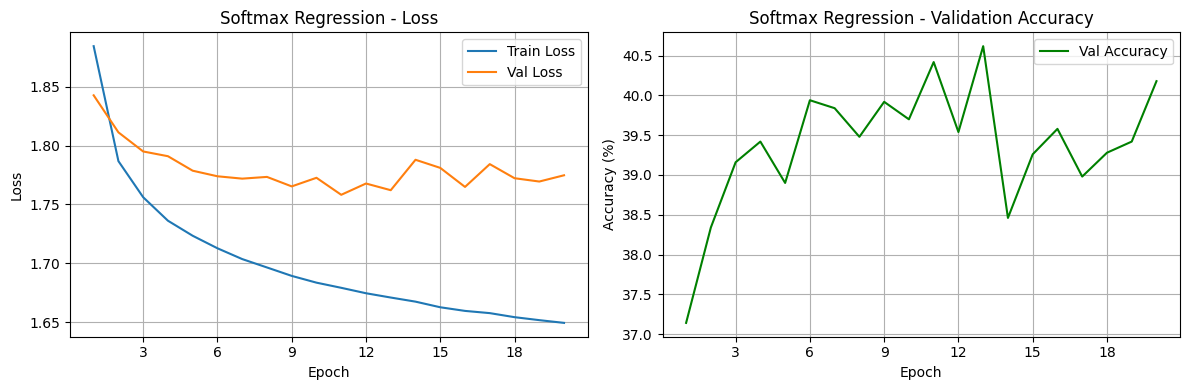

In [17]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # Loss curve
    ax1.plot(epochs, history["train_loss"], label="Train Loss")
    ax1.plot(epochs, history["val_loss"], label="Val Loss")
    ax1.set_title(f"{title} - Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    # Accuracy curve
    ax2.plot(epochs, history["val_acc"], label="Val Accuracy", color="green")
    ax2.set_title(f"{title} - Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

plot_history(softmax_history, "Softmax Regression")

Convolutional Neural Network (CNN)

A configurable CNN architecture is implemented to allow variation in depth, use of residual connections, and dropout rate. The model consists of convolutional layers with Batch Normalisation and ReLU activations, followed by max pooling and a fully connected output layer.

Residual connections are optionally included to improve gradient flow in deeper networks, while dropout and weight decay are used to reduce overfitting.

In [11]:
class CNN(nn.Module):
    def __init__(self, num_conv_layers=2, use_residual=False, dropout_rate=0.0):
        super(CNN, self).__init__()

        self.use_residual = use_residual
        self.num_conv_layers = num_conv_layers

        # First conv layer
        self.first_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # Middle conv layers
        self.conv_layers = nn.ModuleList()
        for _ in range(num_conv_layers - 2):
            self.conv_layers.append(nn.Sequential(
                nn.Conv2d(64, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.Dropout2d(dropout_rate)
            ))

        # Last conv layer before pooling
        self.last_conv = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(64 * 16 * 16, 10)

    def forward(self, x):
        x = self.first_conv(x)

        for layer in self.conv_layers:
            if self.use_residual:
                x = x + layer(x)
            else:
                x = layer(x)

        x = self.last_conv(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

Experiment (a): Effect of Network Depth

This experiment investigates how increasing the number of convolutional layers affects model performance. Models of varying depth are trained and compared to observe changes in accuracy, convergence behaviour, and overfitting.

In [ ]:
depths = [2, 8, 16, 32]
cnn_histories = {}

for depth in depths:
    print(f"\n{'='*50}")
    print(f"Training CNN with {depth} conv layers (no regularisation)")
    print(f"{'='*50}")

    model = CNN(num_conv_layers=depth).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    history = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=20
    )

    cnn_histories[f"depth_{depth}"] = history
    plot_history(history, f"CNN Depth {depth}")

print("\nBaseline depth analysis complete!")

Regularisation of Deep Networks

Deeper models are retrained with residual connections, dropout, and weight decay to improve stability and generalisation. This experiment evaluates how these techniques mitigate overfitting and improve performance in deeper architectures.

In [ ]:
reg_configs = [
    {"depth": 16, "use_residual": True,  "dropout_rate": 0.3, "weight_decay": 1e-4},
    {"depth": 32, "use_residual": True,  "dropout_rate": 0.3, "weight_decay": 1e-4},
]

reg_histories = {}

for config in reg_configs:
    depth = config["depth"]
    print(f"\n{'='*50}")
    print(f"Training CNN - {depth} layers with regularisation")
    print(f"Residual: True | Dropout: {config['dropout_rate']} | Weight Decay: {config['weight_decay']}")
    print(f"{'='*50}")

    model = CNN(
        num_conv_layers=depth,
        use_residual=config["use_residual"],
        dropout_rate=config["dropout_rate"]
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=config["weight_decay"]
    )
    criterion = nn.CrossEntropyLoss()

    history = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=20
    )

    key = f"depth_{depth}_reg"
    reg_histories[key] = history
    plot_history(history, f"CNN Depth {depth} Regularised")

print("\nRegularised depth analysis complete!")

Experiment (b): Learning Rate Analysis

This experiment evaluates the impact of different learning rates on model training. The goal is to identify a learning rate that balances convergence speed with training stability.

In [ ]:
learning_rates = [0.000001, 0.0001, 0.001, 0.01, 1.0]
lr_histories = {}

for lr in learning_rates:
    print(f"\n{'='*50}")
    print(f"Training with Learning Rate: {lr}")
    print(f"{'='*50}")

    model = CNN(
        num_conv_layers=16,
        use_residual=True,
        dropout_rate=0.3
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )
    criterion = nn.CrossEntropyLoss()

    history = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=20
    )

    lr_histories[f"lr_{lr}"] = history
    plot_history(history, f"Learning Rate {lr}")

print("\nLearning rate analysis complete!")

Experiment (c): Mini-batch Size Study

This experiment analyses how different batch sizes affect training stability, computational cost, and final model performance. Smaller batch sizes introduce noisier updates, while larger batch sizes provide smoother gradient estimates.

In [ ]:
batch_sizes = [1, 8, 16, 64, 256]
batch_histories = {}

for batch_size in batch_sizes:
    # Use fewer epochs for batch size 1
    epochs = 10 if batch_size == 1 else 20

    print(f"\n{'='*50}")
    print(f"Training with Batch Size: {batch_size} for {epochs} epochs")
    print(f"{'='*50}")

    # Recreate data loaders with new batch size
    train_loader_b = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader_b   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)

    model = CNN(num_conv_layers=16, use_residual=True, dropout_rate=0.3)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    history = train_model(model, train_loader_b, val_loader_b,
                         optimizer, criterion, epochs=epochs)

    batch_histories[f"batch_{batch_size}"] = history
    plot_history(history, f"Batch Size {batch_size}")

print("\nMini-batch size study complete!")

Final Model Selection

Based on the experimental results, a final model configuration is selected using a 16-layer CNN with residual connections, dropout, and weight decay. A learning rate of 0.001 and batch size of 256 are used, as these provided the best balance of performance and stability.

The model is retrained and evaluated on the test set to obtain an unbiased estimate of its performance.

Retraining best model (16 layer regularised, lr=0.001, batch=256)...
Epoch 1/20 | Train Loss: 2.1650 | Val Loss: 1.5493 | Val Acc: 44.76%
Epoch 2/20 | Train Loss: 1.4064 | Val Loss: 1.3158 | Val Acc: 53.54%
Epoch 3/20 | Train Loss: 1.2192 | Val Loss: 1.1591 | Val Acc: 59.42%
Epoch 4/20 | Train Loss: 1.0986 | Val Loss: 1.0250 | Val Acc: 64.20%
Epoch 5/20 | Train Loss: 1.0124 | Val Loss: 0.9960 | Val Acc: 64.82%
Epoch 6/20 | Train Loss: 0.9218 | Val Loss: 0.8671 | Val Acc: 69.84%
Epoch 7/20 | Train Loss: 0.8573 | Val Loss: 0.8277 | Val Acc: 71.86%
Epoch 8/20 | Train Loss: 0.8030 | Val Loss: 0.8150 | Val Acc: 72.28%
Epoch 9/20 | Train Loss: 0.7552 | Val Loss: 0.7765 | Val Acc: 73.32%
Epoch 10/20 | Train Loss: 0.7130 | Val Loss: 0.7601 | Val Acc: 73.38%
Epoch 11/20 | Train Loss: 0.6724 | Val Loss: 0.7320 | Val Acc: 74.72%
Epoch 12/20 | Train Loss: 0.6396 | Val Loss: 0.7233 | Val Acc: 75.64%
Epoch 13/20 | Train Loss: 0.6054 | Val Loss: 0.7077 | Val Acc: 76.36%
Epoch 14/20 | Train Loss: 0.57

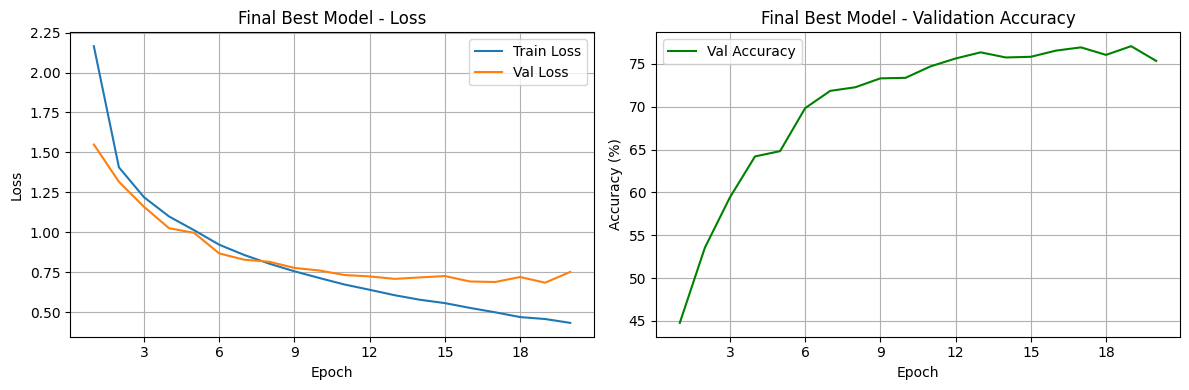


FINAL TEST SET RESULTS
Test Loss:     0.7426
Test Accuracy: 75.34%


In [18]:
def evaluate_test(model, test_loader, criterion):
    model = model.to(device)
    model.eval()

    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


# Retrain best model for test evaluation
print("Retraining best model (16 layer regularised, lr=0.001, batch=256)...")
criterion = nn.CrossEntropyLoss()

best_model = CNN(
    num_conv_layers=16,
    use_residual=True,
    dropout_rate=0.3
).to(device)

optimizer = optim.Adam(
    best_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

best_history = train_model(
    best_model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=20
)

plot_history(best_history, "Final Best Model")

# Evaluate on test set
test_loss, test_acc = evaluate_test(best_model, test_loader, criterion)

print(f"\n{'='*50}")
print("FINAL TEST SET RESULTS")
print(f"{'='*50}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")